# 🧠🤖 第6周-Day2：Function Calling详解

## 📚 今日学习目标

掌握Function Calling的核心概念，理解LLM如何调用外部工具，并通过实际代码练习掌握工具调用的完整流程。

### 🔍 什么是Function Calling？

Function Calling让LLM能够突破自身知识库的限制，实时调用外部API或函数来获取最新信息、执行特定任务。就像给AI装上了"手"，让它能够"动手"做事！

💡 **生活类比**：
- Function Calling = AI的"电话本"，让它能打电话给外界
- 工具定义 = 每个电话号码的使用说明
- 调用决策 = AI决定什么时候打电话 vs 直接回答

### 🎯 学习路线

1. 理解Function Calling的工作原理
2. 掌握工具定义的三要素
3. 学习调用决策的逻辑
4. 实践代码实现
5. 优化和调试技巧


In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import shutil

# 清除 matplotlib 字体缓存
cache_dir = matplotlib.get_cachedir()
for item in os.listdir(cache_dir):
    if item.startswith('fontlist'):
        path = os.path.join(cache_dir, item)
        try:
            if os.path.isfile(path):
                os.remove(path)
            elif os.path.isdir(path):
                shutil.rmtree(path)
        except (PermissionError, OSError) as e:
            print(f'⚠️ 无法删除字体缓存 {item}: {e}')

# 重新构建字体列表
fm._load_fontmanager(try_read_cache=False)

# 验证字体是否存在
available_fonts = [f.name for f in fm.fontManager.ttflist]
preferred_fonts = ['WenQuanYi Zen Hei', 'DejaVu Sans']
selected_fonts = [f for f in preferred_fonts if f in available_fonts]

if not selected_fonts:
    print('❌ 警告：未找到可用的中文字体！')
else:
    print(f'✅ 使用中文字体: {selected_fonts[0]}')

# 配置中文字体
plt.rcParams['font.sans-serif'] = selected_fonts
plt.rcParams['axes.unicode_minus'] = False
print('✅ 中文字体配置完成')

# 导入必要的库
import numpy as np
import json
import requests
import time

✅ 使用中文字体: WenQuanYi Zen Hei
✅ 中文字体配置完成


## 🔧 Function Calling工作原理

Function Calling的核心流程可以分为三个步骤：

1. **意图识别**：LLM理解用户的问题
2. **工具选择**：判断是否需要调用工具，选择哪个工具
3. **参数提取**：从用户请求中提取工具需要的参数

### 📊 可视化工作流程

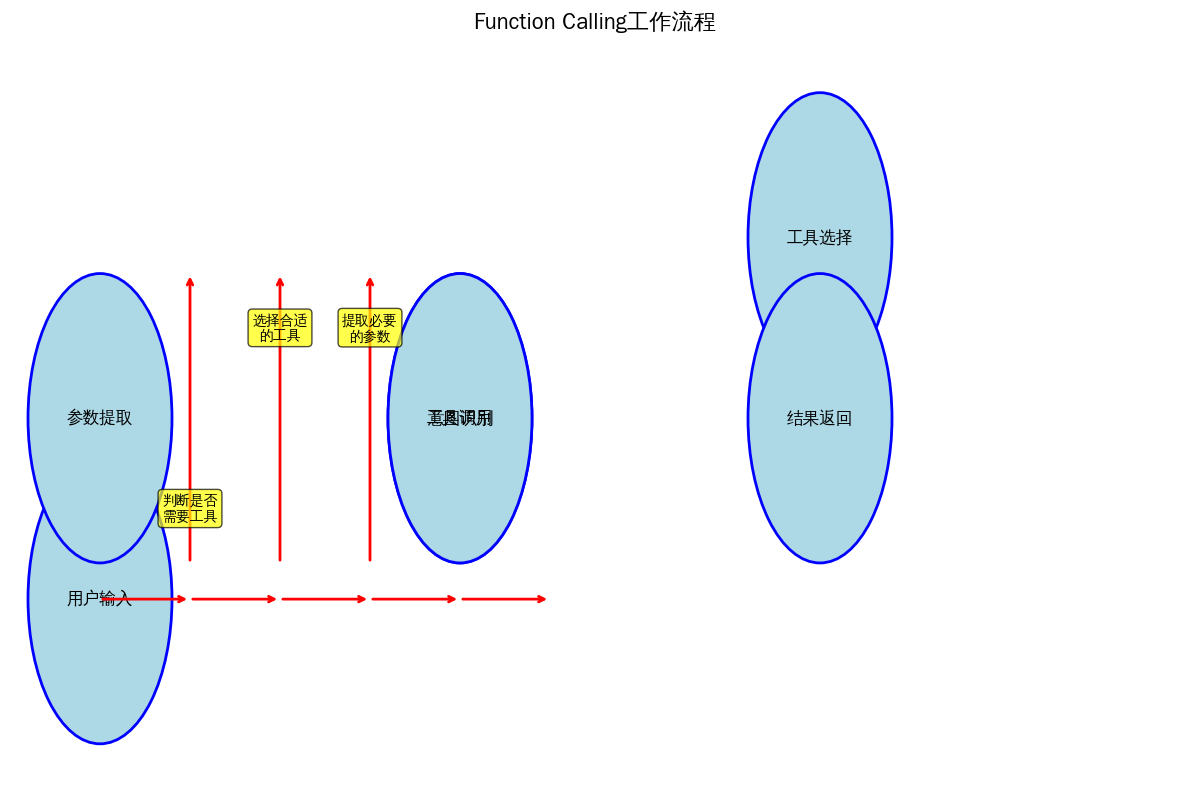

In [3]:
# Function Calling工作流程可视化
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# 工作流程节点
nodes = [
    ("用户输入", 1),
    ("意图识别", 2),
    ("工具选择", 3),
    ("参数提取", 4),
    ("工具调用", 5),
    ("结果返回", 6)
]

# 绘制流程图
for i, (node, y_pos) in enumerate(nodes):
    x_pos = (i % 3) * 4 + 1
    if i >= 3:
        y_pos = 2
    
    # 绘制节点
    circle = plt.Circle((x_pos, y_pos), 0.8, color='lightblue', ec='blue', linewidth=2)
    ax.add_patch(circle)
    ax.text(x_pos, y_pos, node, ha='center', va='center', fontsize=12, fontweight='bold')

# 绘制箭头
arrows = [
    ((1, 1), (2, 1)), ((2, 1), (3, 1)), ((3, 1), (4, 1)),
    ((4, 1), (5, 1)), ((5, 1), (6, 1)),
    ((2, 1.2), (2, 2.8)), ((3, 1.2), (3, 2.8)), ((4, 1.2), (4, 2.8))
]

for start, end in arrows:
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', lw=2, color='red'))

# 添加说明文字
ax.text(2, 1.5, '判断是否\n需要工具', ha='center', va='center', fontsize=10, 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
ax.text(3, 2.5, '选择合适\n的工具', ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
ax.text(4, 2.5, '提取必要\n的参数', ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_xlim(0, 13)
ax.set_ylim(0, 4)
ax.set_title('Function Calling工作流程', fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


## 🛠️ 工具定义的三要素

每个工具（函数）的定义必须包含三个关键要素：

### 1. **工具名称（Tool Name）**
- 清晰的动词+名词结构
- 避免歧义，易于理解

### 2. **参数定义（Parameters）**
- 每个参数：类型、是否必需、描述
- 支持复杂类型：数组、对象等

### 3. **工具描述（Description）**
- 详细说明工具的功能和用途
- 包含使用场景和返回值说明

### 📋 工具定义示例

/tmp/ipykernel_449103/3761050226.py:43: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) WenQuanYi Zen Hei.
  plt.tight_layout()
/tmp/ipykernel_449103/3761050226.py:43: UserWarning: Glyph 8226 (\N{BULLET}) missing from font(s) WenQuanYi Zen Hei.
  plt.tight_layout()
/tmp/ipykernel_449103/3761050226.py:43: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) WenQuanYi Zen Hei.
  plt.tight_layout()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) WenQuanYi Zen Hei.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8226 (\N{BULLET}) missing from font(s) WenQuanYi Zen Hei.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEA

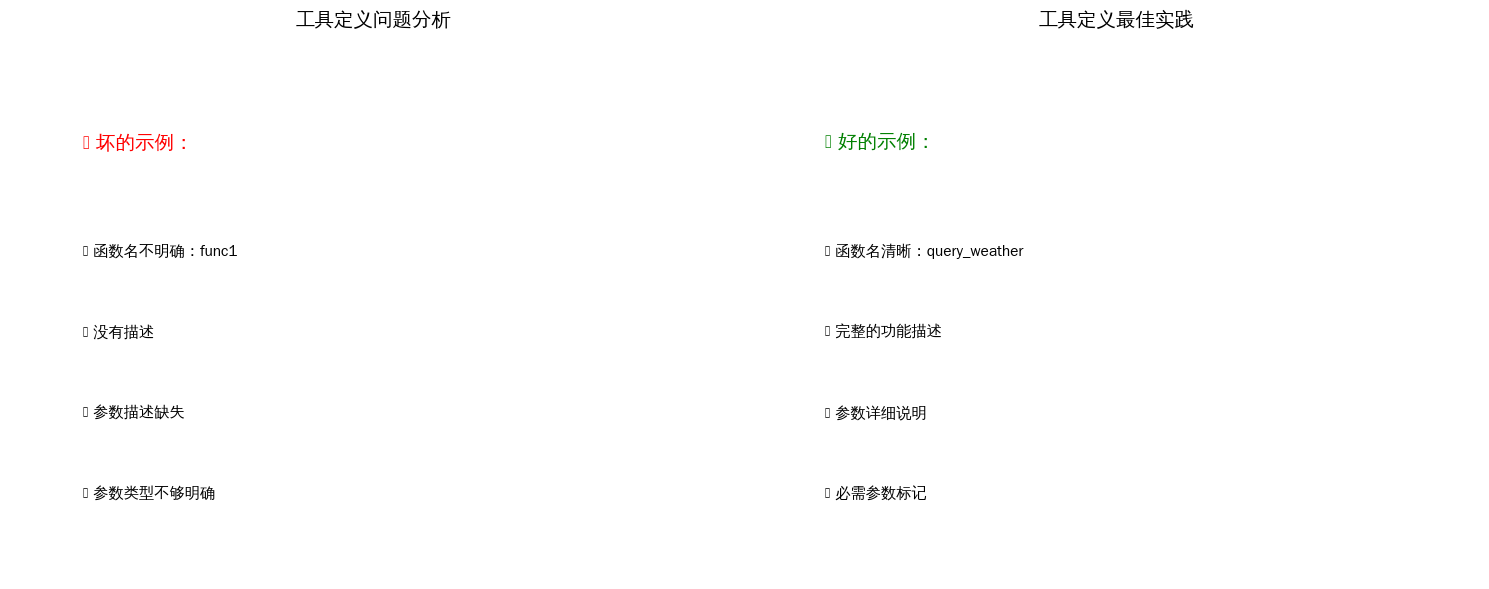

In [4]:
# 工具定义示例对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 坏的工具定义示例
bad_example = {
    "name": "func1",
    "parameters": {
        "x": {"type": "string"},
        "y": {"type": "number"}
    }
}

# 好的工具定义示例
good_example = {
    "name": "query_weather",
    "description": "根据城市名称查询实时天气信息，包括温度、湿度、天气状况等",
    "parameters": {
        "city": {
            "type": "string",
            "description": "城市名称，如北京、上海、广州等",
            "required": True
        }
    }
}

# 可视化对比
ax1.text(0.1, 0.8, '❌ 坏的示例：', fontsize=14, fontweight='bold', color='red', transform=ax1.transAxes)
ax1.text(0.1, 0.6, '• 函数名不明确：func1', fontsize=11, transform=ax1.transAxes)
ax1.text(0.1, 0.45, '• 没有描述', fontsize=11, transform=ax1.transAxes)
ax1.text(0.1, 0.3, '• 参数描述缺失', fontsize=11, transform=ax1.transAxes)
ax1.text(0.1, 0.15, '• 参数类型不够明确', fontsize=11, transform=ax1.transAxes)
ax1.set_title('工具定义问题分析', fontsize=14, fontweight='bold', pad=10)
ax1.axis('off')

ax2.text(0.1, 0.8, '✅ 好的示例：', fontsize=14, fontweight='bold', color='green', transform=ax2.transAxes)
ax2.text(0.1, 0.6, '• 函数名清晰：query_weather', fontsize=11, transform=ax2.transAxes)
ax2.text(0.1, 0.45, '• 完整的功能描述', fontsize=11, transform=ax2.transAxes)
ax2.text(0.1, 0.3, '• 参数详细说明', fontsize=11, transform=ax2.transAxes)
ax2.text(0.1, 0.15, '• 必需参数标记', fontsize=11, transform=ax2.transAxes)
ax2.set_title('工具定义最佳实践', fontsize=14, fontweight='bold', pad=10)
ax2.axis('off')

plt.tight_layout()
plt.show()


## 🤖 LLM调用决策逻辑

LLM需要智能判断何时调用工具，何时直接回答。这个决策过程基于两个关键因素：

### 🔍 决策条件

**调用工具的条件：**
- 需要实时数据（天气、股票、汇率等）
- 需要执行特定操作（计算、文件操作、网络请求）
- 需要访问外部知识库（数据库、文档）
- 需要专业领域知识（法律、医疗、财务）

**直接回答的条件：**
- 知识库中有足够信息
- 问题是常识性问题
- 不需要外部验证或执行

### 📊 决策流程可视化

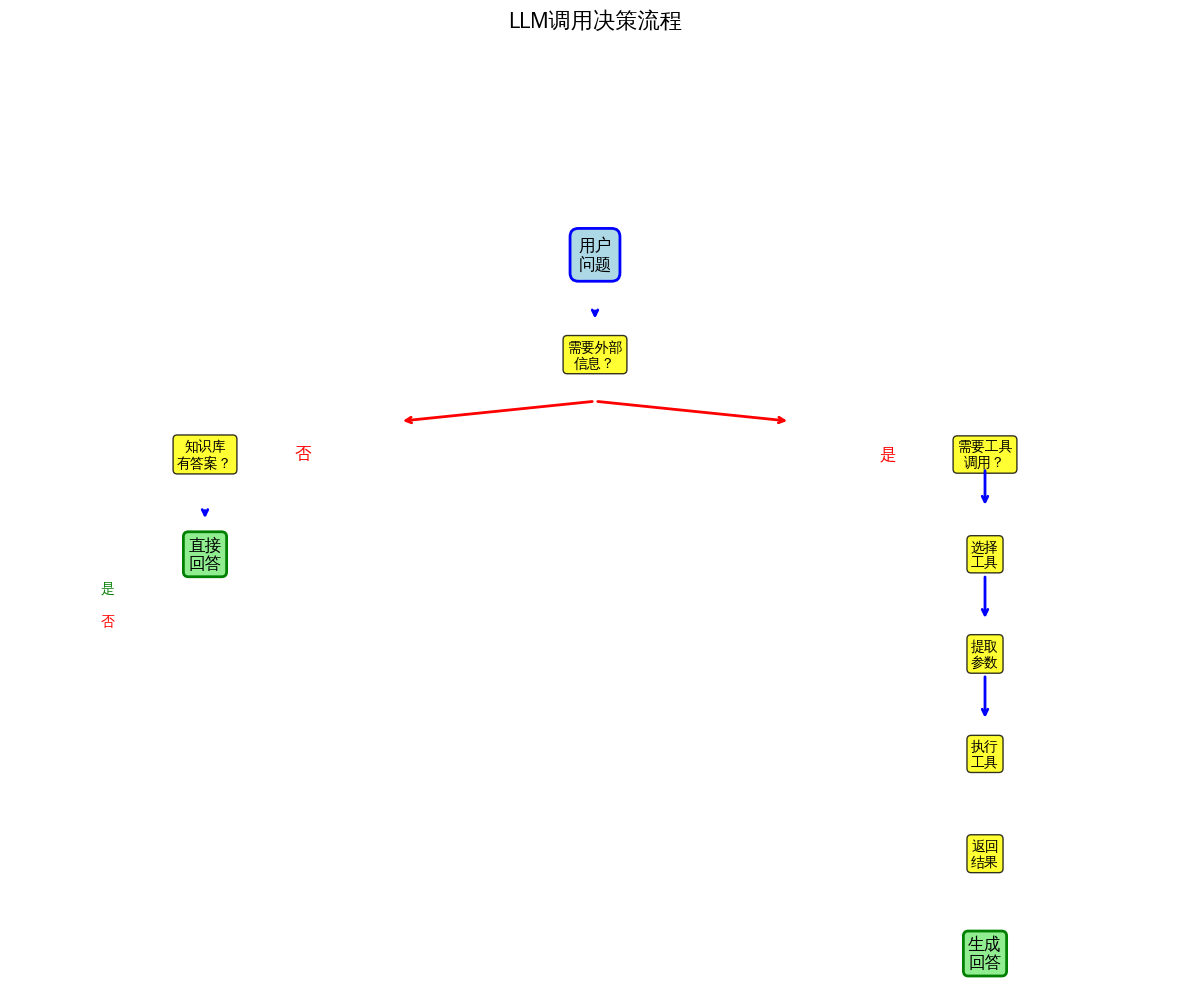

In [4]:
# 决策流程可视化
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# 绘制决策树
start_x, start_y = 6, 8
ax.text(start_x, start_y, '用户\n问题', ha='center', va='center', fontsize=12, 
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', ec='blue', linewidth=2))

# 第一个判断：需要外部信息？
ax.text(start_x, start_y-1.5, '需要外部\n信息？', ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))

# 左分支：直接回答
ax.text(2, start_y-3, '知识库\n有答案？', ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))
ax.text(2, start_y-4.5, '直接\n回答', ha='center', va='center', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', ec='green', linewidth=2))

# 右分支：工具调用
ax.text(10, start_y-3, '需要工具\n调用？', ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))
ax.text(10, start_y-4.5, '选择\n工具', ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))
ax.text(10, start_y-6, '提取\n参数', ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))
ax.text(10, start_y-7.5, '执行\n工具', ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))
ax.text(10, start_y-9, '返回\n结果', ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))
ax.text(10, start_y-10.5, '生成\n回答', ha='center', va='center', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', ec='green', linewidth=2))

# 绘制箭头
ax.annotate('', xy=(start_x, start_y-1), xytext=(start_x, start_y-0.8),
            arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
ax.annotate('', xy=(4, start_y-2.5), xytext=(start_x, start_y-2.2),
            arrowprops=dict(arrowstyle='->', lw=2, color='red'))
ax.annotate('', xy=(2, start_y-4), xytext=(2, start_y-3.8),
            arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
ax.annotate('', xy=(8, start_y-2.5), xytext=(start_x, start_y-2.2),
            arrowprops=dict(arrowstyle='->', lw=2, color='red'))
ax.annotate('', xy=(10, start_y-3.8), xytext=(10, start_y-3.2),
            arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
ax.annotate('', xy=(10, start_y-5.5), xytext=(10, start_y-4.8),
            arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
ax.annotate('', xy=(10, start_y-7), xytext=(10, start_y-6.3),
            arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
ax.annotate('', xy=(10, start_y-8.3), xytext=(10, start_y-7.8),
            arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
ax.annotate('', xy=(10, start_y-10), xytext=(10, start_y-9.3),
            arrowprops=dict(arrowstyle='->', lw=2, color='blue'))

# 添加标注
ax.text(3, start_y-3, '否', ha='center', va='center', fontsize=12, fontweight='bold', color='red')
ax.text(9, start_y-3, '是', ha='center', va='center', fontsize=12, fontweight='bold', color='red')
ax.text(1, start_y-5, '是', ha='center', va='center', fontsize=10, fontweight='bold', color='green')
ax.text(1, start_y-5.5, '否', ha='center', va='center', fontsize=10, fontweight='bold', color='red')

ax.set_xlim(0, 12)
ax.set_ylim(0, 11)
ax.set_title('LLM调用决策流程', fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()
